In [1]:
!pip install yfinance --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = yf.download("AAPL", start="2015-01-01", auto_adjust=False, progress=False)
df.to_csv("AAPL_raw.csv")
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,24.171759,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.490803,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.493010,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.822437,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.737747,27.972500,28.037500,27.174999,27.307501,237458000


Data Exploration Process

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2918 entries, 2015-01-02 to 2026-08-11
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  2918 non-null   float64
 1   (Close, AAPL)      2918 non-null   float64
 2   (High, AAPL)       2918 non-null   float64
 3   (Low, AAPL)        2918 non-null   float64
 4   (Open, AAPL)       2918 non-null   float64
 5   (Volume, AAPL)     2918 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 159.6 KB


In [5]:
df.shape

(2918, 6)

In [6]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,2918.000000,2918.000000,2918.000000,2918.000000,2918.000000,2.918000e+03
mean,115.179748,117.674602,118.852499,116.382347,117.563336,1.082604e+08
std,82.238314,81.781303,82.590201,80.881056,81.679397,6.780156e+07
min,20.548145,22.584999,22.917500,22.367500,22.500000,1.791060e+07
25%,37.441740,40.216875,40.552500,39.773749,40.105624,6.039668e+07
50%,113.311592,116.920002,119.024998,115.781250,117.519997,9.102065e+07
75%,175.068943,177.720005,179.417496,175.815006,177.290005,1.343892e+08
max,339.786926,340.079987,344.570007,337.350006,340.029999,6.488252e+08


In [8]:
df[('Adj Close', 'AAPL')].describe()

,Adj Close
,AAPL
count,2918.000000
mean,115.179748
std,82.238314
min,20.548145
25%,37.441740
50%,113.311592
75%,175.068943
max,339.786926


In [10]:
df[('Close', 'AAPL')].describe()

,Close
,AAPL
count,2918.000000
mean,117.674602
std,81.781303
min,22.584999
25%,40.216875
50%,116.920002
75%,177.720005
max,340.079987


In [11]:
df[('High', 'AAPL')].describe()

,High
,AAPL
count,2918.000000
mean,118.852499
std,82.590201
min,22.917500
25%,40.552500
50%,119.024998
75%,179.417496
max,344.570007


In [12]:
df[('Low', 'AAPL')].describe()

,Low
,AAPL
count,2918.000000
mean,116.382347
std,80.881056
min,22.367500
25%,39.773749
50%,115.781250
75%,175.815006
max,337.350006


In [13]:
df[('Open', 'AAPL')].describe()

,Open
,AAPL
count,2918.000000
mean,117.563336
std,81.679397
min,22.500000
25%,40.105624
50%,117.519997
75%,177.290005
max,340.029999


In [14]:
df[('Volume', 'AAPL')].describe()

,Volume
,AAPL
count,2.918000e+03
mean,1.082604e+08
std,6.780156e+07
min,1.791060e+07
25%,6.039668e+07
50%,9.102065e+07
75%,1.343892e+08
max,6.488252e+08


Data Preprocessing

In [23]:
df.isnull().sum()

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [25]:
df.duplicated().sum()

np.int64(0)

In [4]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
df.columns.name = None

df = df.rename(columns={"Adj Close": "Adj_Close"})
df.index.name = "Date"
df = df[["Open", "High", "Low", "Close", "Adj_Close", "Volume"]]
df.head()

,Open,High,Low,Close,Adj_Close,Volume
Date,,,,,,
2015-01-02,27.847500,27.860001,26.837500,27.332500,24.171759,212818400
2015-01-05,27.072500,27.162500,26.352501,26.562500,23.490803,257142000
2015-01-06,26.635000,26.857500,26.157499,26.565001,23.493010,263188400
2015-01-07,26.799999,27.049999,26.674999,26.937500,23.822437,160423600
2015-01-08,27.307501,28.037500,27.174999,27.972500,24.737747,237458000


In [6]:
df = df.sort_index()
df = df[~df.index.duplicated(keep="first")]
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

invalid = df[(df["High"] < df["Low"]) | (df["Close"] > df["High"]) | (df["Close"] < df["Low"])]
print("Invalid rows:", len(invalid))
print("Final shape:", df.shape)

Invalid rows: 0
Final shape: (2919, 6)


In [28]:
print(df.dtypes)

Open         float64
High         float64
Low          float64
Close        float64
Adj_Close    float64
Volume         int64
dtype: object


Data Transformation



In [29]:
df["Daily_Return_%"] = df["Adj_Close"].pct_change() * 100
df[["Adj_Close", "Daily_Return_%"]].head()

,Adj_Close,Daily_Return_%
Date,,
2015-01-02,24.171759,NaN
2015-01-05,23.490797,-2.817179
2015-01-06,23.493015,0.009443
2015-01-07,23.822426,1.402164
2015-01-08,24.737747,3.842268


In [30]:
df["Daily_Change"] = df["Adj_Close"].diff()
df[["Adj_Close", "Daily_Change", "Daily_Return_%"]].head()

,Adj_Close,Daily_Change,Daily_Return_%
Date,,,
2015-01-02,24.171759,NaN,NaN
2015-01-05,23.490797,-0.680962,-2.817179
2015-01-06,23.493015,0.002218,0.009443
2015-01-07,23.822426,0.329411,1.402164
2015-01-08,24.737747,0.915321,3.842268


In [31]:
df["Direction"] = np.where(df["Daily_Return_%"] > 0, "Up", "Down")
df[["Adj_Close", "Daily_Return_%", "Direction"]].head()

,Adj_Close,Daily_Return_%,Direction
Date,,,
2015-01-02,24.171759,NaN,Down
2015-01-05,23.490797,-2.817179,Down
2015-01-06,23.493015,0.009443,Up
2015-01-07,23.822426,1.402164,Up
2015-01-08,24.737747,3.842268,Up


In [32]:
df["Direction"].value_counts()

,count
Direction,
Up,1550
Down,1368


In [33]:
df["Year"] = df.index.year
df[["Adj_Close", "Daily_Return_%", "Year"]].head()

,Adj_Close,Daily_Return_%,Year
Date,,,
2015-01-02,24.171759,NaN,2015
2015-01-05,23.490797,-2.817179,2015
2015-01-06,23.493015,0.009443,2015
2015-01-07,23.822426,1.402164,2015
2015-01-08,24.737747,3.842268,2015


In [34]:
df["Year"] = df.index.year
df[["Adj_Close", "Daily_Return_%", "Year"]].head()

,Adj_Close,Daily_Return_%,Year
Date,,,
2015-01-02,24.171759,NaN,2015
2015-01-05,23.490797,-2.817179,2015
2015-01-06,23.493015,0.009443,2015
2015-01-07,23.822426,1.402164,2015
2015-01-08,24.737747,3.842268,2015


In [35]:
df["Month_Name"] = df.index.strftime("%b")
df["Day_Name"]   = df.index.day_name()
df[["Year", "Month_Name", "Day_Name"]].head()

,Year,Month_Name,Day_Name
Date,,,
2015-01-02,2015,Jan,Friday
2015-01-05,2015,Jan,Monday
2015-01-06,2015,Jan,Tuesday
2015-01-07,2015,Jan,Wednesday
2015-01-08,2015,Jan,Thursday


In [36]:
df.groupby("Year")["Daily_Return_%"].mean()

,Daily_Return_%
Year,
2015,0.005789
2016,0.057466
2017,0.163656
2018,-0.005726
2019,0.266460
2020,0.280692
2021,0.130573
2022,-0.096961
2023,0.167797


In [38]:
yearly = df.groupby("Year").agg(
    Start_Price  = ("Adj_Close", "first"),
    End_Price    = ("Adj_Close", "last"),
    Avg_Volume   = ("Volume", "mean"),
    Volatility   = ("Daily_Return_%", "std"),
)

yearly["Annual_Return_%"] = (yearly["End_Price"] / yearly["Start_Price"] - 1) * 100
yearly.round(2)

,Start_Price,End_Price,Avg_Volume,Volatility,Annual_Return_%
Year,,,,,
2015,24.17,23.67,2.073976e+08,1.69,-2.08
2016,23.69,26.62,1.536901e+08,1.47,12.38
2017,26.70,39.52,1.085383e+08,1.11,48.04
2018,40.23,37.39,1.360803e+08,1.81,-7.05
2019,37.44,70.66,1.121228e+08,1.65,88.74
2020,72.27,128.82,1.575646e+08,2.94,78.24
2021,125.63,173.45,9.052463e+07,1.58,38.06
2022,177.79,127.65,8.791038e+07,2.25,-28.20
2023,122.88,190.21,5.922355e+07,1.28,54.80


In [39]:
df.nlargest(10, "Daily_Return_%")[["Adj_Close", "Daily_Return_%", "Volume"]]

,Adj_Close,Daily_Return_%,Volume
Date,,,
2025-04-09,197.634384,15.328852,184395900
2020-03-13,67.045128,11.980840,370732000
2020-07-31,102.795242,10.468864,374336800
2020-03-24,59.546349,10.032549,287531200
2020-03-02,72.071632,9.310096,341397200
2022-11-10,144.294449,8.897445,118854000
2020-04-06,63.306564,8.723724,201820400
2022-10-28,152.755493,7.555221,164762400
2024-06-11,205.194016,7.264912,172373300


In [40]:
df.nsmallest(10, "Daily_Return_%")[["Adj_Close", "Daily_Return_%", "Volume"]]

,Adj_Close,Daily_Return_%,Volume
Date,,,
2020-03-16,58.419971,-12.864703,322423600
2019-01-03,33.707928,-9.960735,365248800
2020-03-12,59.871964,-9.875424,418474000
2025-04-03,201.947891,-9.245598,103419000
2020-09-03,117.149384,-8.006070,257599600
2020-03-09,64.199020,-7.909177,286744800
2026-07-31,308.643829,-7.353858,132489100
2025-04-04,187.228424,-7.288745,125910900
2020-09-08,109.338135,-6.729488,231366600


In [41]:
big_moves = df[df["Daily_Return_%"].abs() > 5]
print("Days that moved more than 5%:", len(big_moves))
big_moves[["Adj_Close", "Daily_Return_%"]].head()

Days that moved more than 5%: 54


,Adj_Close,Daily_Return_%
Date,,
2015-01-28,25.493874,5.653272
2015-08-11,25.410244,-5.203796
2015-08-21,23.679501,-6.116308
2015-08-26,24.559429,5.735506
2016-01-22,22.804983,5.316704


TIME SERIES ANALYSIS

In [42]:
df["MA_7"]  = df["Adj_Close"].rolling(window=7).mean()
df["MA_30"] = df["Adj_Close"].rolling(window=30).mean()
df[["Adj_Close", "MA_7", "MA_30"]].tail()

,Adj_Close,MA_7,MA_30
Date,,,
2026-08-05,310.732025,320.353716,314.304264
2026-08-06,312.140808,316.404271,314.948044
2026-08-07,313.059998,312.855900,316.219614
2026-08-10,308.260010,309.301235,317.043765
2026-08-11,304.910004,308.767831,317.824191


In [43]:
df["MA_50"]  = df["Adj_Close"].rolling(window=50).mean()
df["MA_200"] = df["Adj_Close"].rolling(window=200).mean()

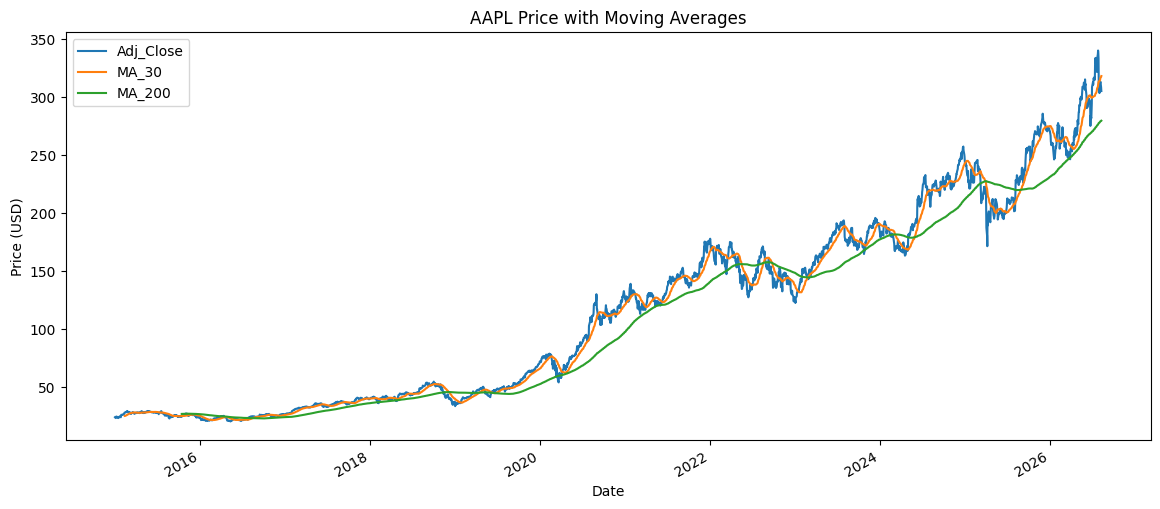

In [44]:
import matplotlib.pyplot as plt

df[["Adj_Close", "MA_30", "MA_200"]].plot(figsize=(14, 6))
plt.title("AAPL Price with Moving Averages")
plt.ylabel("Price (USD)")
plt.show()

In [45]:
import numpy as np

df["Trend"] = np.where(df["Adj_Close"] > df["MA_200"], "Uptrend", "Downtrend")
df["Trend"].value_counts(normalize=True) * 100

,proportion
Trend,
Uptrend,71.17889
Downtrend,28.82111


In [46]:
df["Volatility_30d"] = df["Daily_Return_%"].rolling(window=30).std()
df[["Daily_Return_%", "Volatility_30d"]].tail()

,Daily_Return_%,Volatility_30d
Date,,
2026-08-05,0.523634,2.555689
2026-08-06,0.453376,2.553214
2026-08-07,0.294479,2.252916
2026-08-10,-1.533249,2.222654
2026-08-11,-1.086747,2.229492


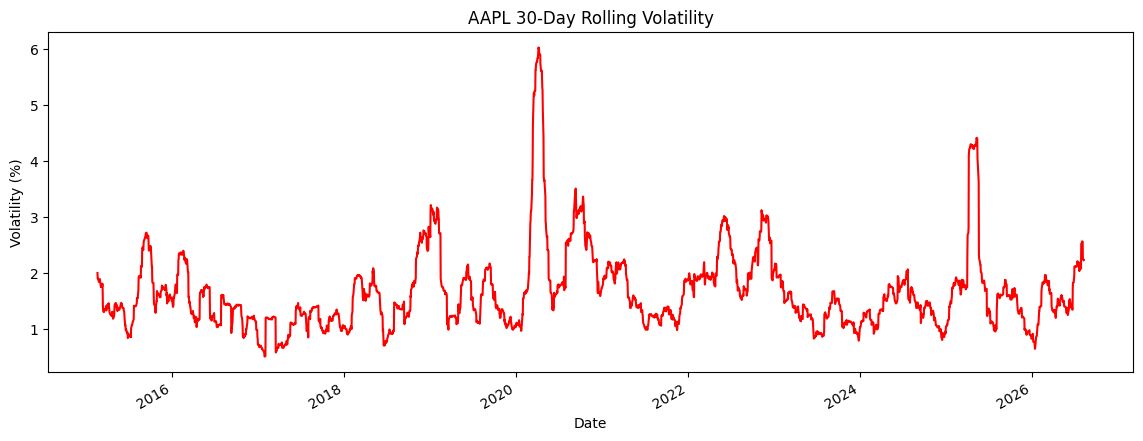

In [47]:
df["Volatility_30d"].plot(figsize=(14, 5), color="red")
plt.title("AAPL 30-Day Rolling Volatility")
plt.ylabel("Volatility (%)")
plt.show()

In [48]:
start = df["Adj_Close"].iloc[0]
end   = df["Adj_Close"].iloc[-1]

total_return = (end / start - 1) * 100

print(f"Started at: ${start:,.2f}")
print(f"Ended at:   ${end:,.2f}")
print(f"Total return: {total_return:,.1f}%")

Started at: $24.17
Ended at:   $304.91
Total return: 1,161.4%


Feature Engineering

In [49]:
df["Vol_MA_30"]    = df["Volume"].rolling(30).mean()
df["Volume_Ratio"] = df["Volume"] / df["Vol_MA_30"]
df[["Volume", "Vol_MA_30", "Volume_Ratio"]].tail()

,Volume,Vol_MA_30,Volume_Ratio
Date,,,
2026-08-05,49438800,6.482504e+07,0.762650
2026-08-06,46139900,6.459364e+07,0.714310
2026-08-07,34437200,6.217443e+07,0.553880
2026-08-10,44812500,5.494233e+07,0.815628
2026-08-11,37401700,5.397482e+07,0.692947


In [50]:
df["Price_vs_MA30_%"] = (df["Adj_Close"] / df["MA_30"] - 1) * 100
df[["Adj_Close", "MA_30", "Price_vs_MA30_%"]].tail()

,Adj_Close,MA_30,Price_vs_MA30_%
Date,,,
2026-08-05,310.732025,314.304264,-1.136554
2026-08-06,312.140808,314.948044,-0.891333
2026-08-07,313.059998,316.219614,-0.999184
2026-08-10,308.260010,317.043765,-2.770518
2026-08-11,304.910004,317.824191,-4.063312


In [51]:
df["Return_lag_1"] = df["Daily_Return_%"].shift(1)
df[["Daily_Return_%", "Return_lag_1"]].head()

,Daily_Return_%,Return_lag_1
Date,,
2015-01-02,NaN,NaN
2015-01-05,-2.817179,NaN
2015-01-06,0.009443,-2.817179
2015-01-07,1.402164,0.009443
2015-01-08,3.842268,1.402164


In [52]:
features = ["Daily_Change", "Daily_Return_%", "MA_7", "MA_30", "MA_200",
            "Volatility_30d", "Volume_Ratio", "Price_vs_MA30_%", "Return_lag_1"]

print("Features created:", len(features))
df[features].tail()

Features created: 9


,Daily_Change,Daily_Return_%,MA_7,MA_30,MA_200,Volatility_30d,Volume_Ratio,Price_vs_MA30_%,Return_lag_1
Date,,,,,,,,,
2026-08-05,1.618622,0.523634,320.353716,314.304264,278.327934,2.555689,0.762650,-1.136554,1.964264
2026-08-06,1.408783,0.453376,316.404271,314.948044,278.631830,2.553214,0.714310,-0.891333,0.523634
2026-08-07,0.919189,0.294479,312.855900,316.219614,278.890756,2.252916,0.553880,-0.999184,0.453376
2026-08-10,-4.799988,-1.533249,309.301235,317.043765,279.123042,2.222654,0.815628,-2.770518,0.294479
2026-08-11,-3.350006,-1.086747,308.767831,317.824191,279.360098,2.229492,0.692947,-4.063312,-1.533249


Visualizations

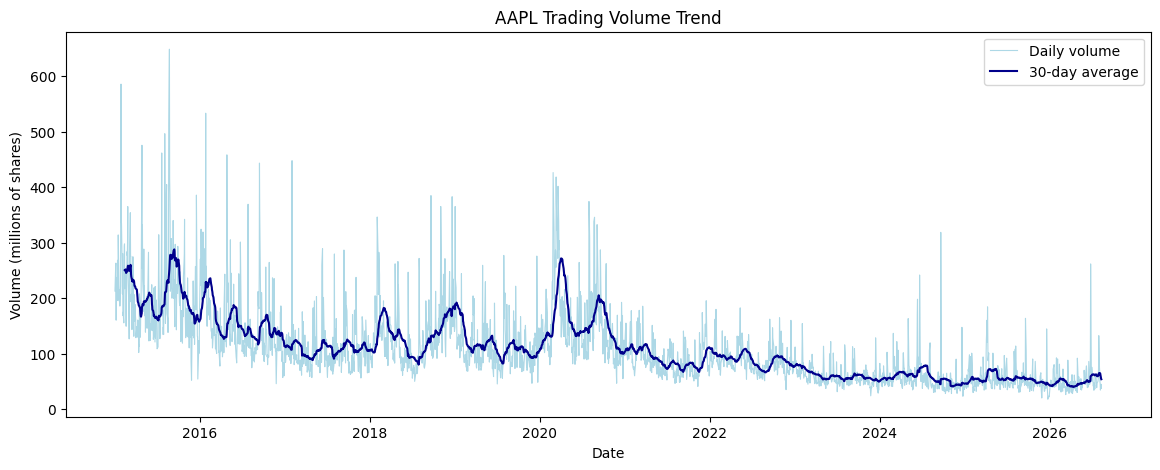

In [53]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Volume"] / 1e6, color="lightblue", linewidth=0.8, label="Daily volume")
plt.plot(df.index, df["Vol_MA_30"] / 1e6, color="darkblue", linewidth=1.5, label="30-day average")
plt.title("AAPL Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume (millions of shares)")
plt.legend()
plt.show()

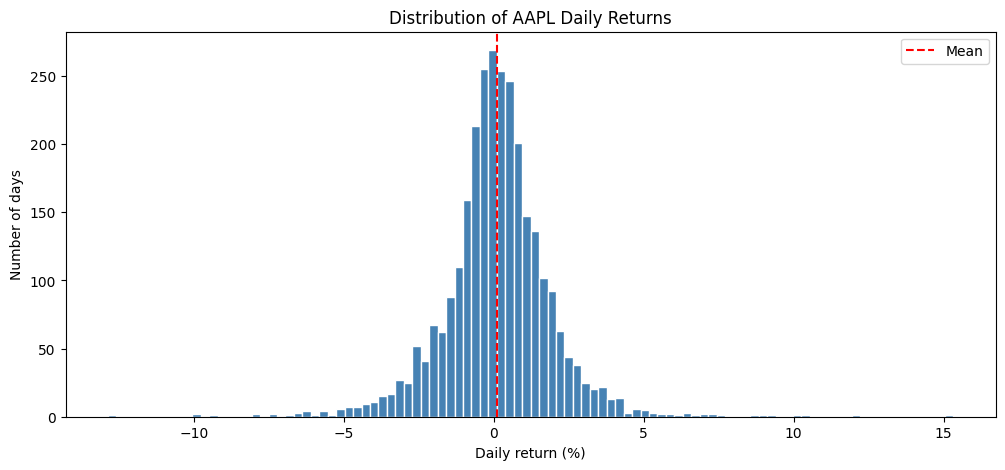

In [54]:
plt.figure(figsize=(12, 5))
plt.hist(df["Daily_Return_%"].dropna(), bins=100, color="steelblue", edgecolor="white")
plt.axvline(df["Daily_Return_%"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily return (%)")
plt.ylabel("Number of days")
plt.legend()
plt.show()

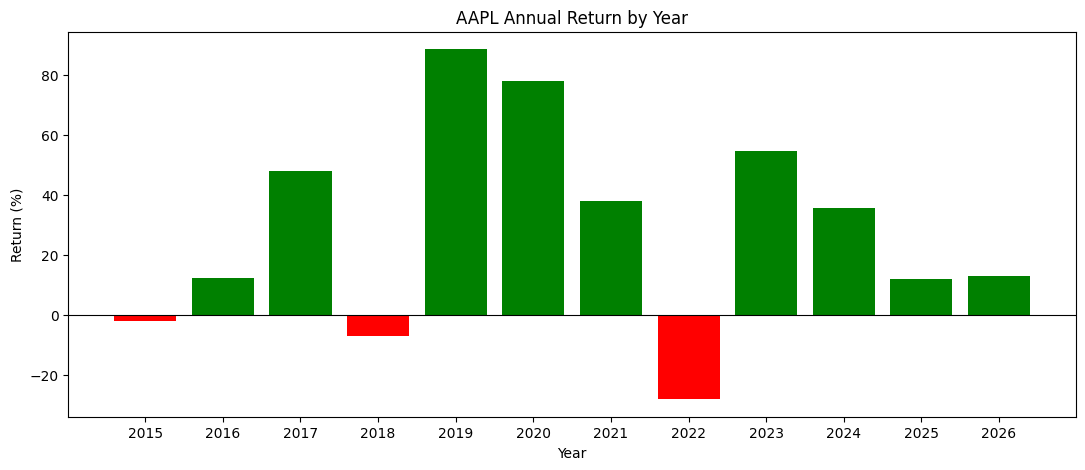

In [55]:
plt.figure(figsize=(13, 5))

colors = ["green" if v > 0 else "red" for v in yearly["Annual_Return_%"]]
plt.bar(yearly.index.astype(str), yearly["Annual_Return_%"], color=colors)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("AAPL Annual Return by Year")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.show()

In [58]:
up_days   = (df["Daily_Return_%"] > 0).sum()
down_days = (df["Daily_Return_%"] < 0).sum()

# Calculate CAGR
start_price = df['Adj_Close'].iloc[0]
end_price = df['Adj_Close'].iloc[-1]
num_years = (df.index.max() - df.index.min()).days / 365.25
cagr = ((end_price / start_price) ** (1 / num_years) - 1) * 100

# Calculate Max Drawdown
# Calculate the running maximum
running_max = df['Adj_Close'].cummax()
# Calculate the daily drawdown
drawdown = (df['Adj_Close'] / running_max - 1) * 100
df['Drawdown_%'] = drawdown

print("PERIOD")
print("  From:", df.index.min().date(), "to", df.index.max().date())
print("  Trading days:", len(df))

print("\nPERFORMANCE")
print(f"  Start price:   ${df['Adj_Close'].iloc[0]:,.2f}")
print(f"  End price:     ${df['Adj_Close'].iloc[-1]:,.2f}")
print(f"  Total return:  {total_return:,.1f}%")
print(f"  CAGR:          {cagr:.2f}%")
print(f"  Best year:     {yearly['Annual_Return_%'].idxmax()} ({yearly['Annual_Return_%'].max():.1f}%)")
print(f"  Worst year:    {yearly['Annual_Return_%'].idxmin()} ({yearly['Annual_Return_%'].min():.1f}%)")

print("\nRISK")
print(f"  Daily volatility: {df['Daily_Return_%'].std():.2f}%")
print(f"  Best day:         {df['Daily_Return_%'].max():.2f}%")
print(f"  Worst day:        {df['Daily_Return_%'].min():.2f}%")
print(f"  Max drawdown:     {df['Drawdown_%'].min():.2f}%")

print("\nBEHAVIOUR")
print(f"  Up days:   {up_days:,} ({up_days/(up_days+down_days)*100:.1f}%)")
print(f"  Down days: {down_days:,} ({down_days/(up_days+down_days)*100:.1f}%)")
print(f"  Avg volume: {df['Volume'].mean()/1e6:,.1f}m shares")

PERIOD
  From: 2015-01-02 to 2026-08-11
  Trading days: 2918

PERFORMANCE
  Start price:   $24.17
  End price:     $304.91
  Total return:  1,161.4%
  CAGR:          24.41%
  Best year:     2019 (88.7%)
  Worst year:    2022 (-28.2%)

RISK
  Daily volatility: 1.81%
  Best day:         15.33%
  Worst day:        -12.86%
  Max drawdown:     -38.52%

BEHAVIOUR
  Up days:   1,550 (53.2%)
  Down days: 1,361 (46.8%)
  Avg volume: 108.3m shares
